# **Exploration & Data Loading**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('renewable-water-resources-per-capita.csv')
print(df.head())
print(df.columns)

        Entity Code  Year  \
0  Afghanistan  AFG  1962   
1  Afghanistan  AFG  1963   
2  Afghanistan  AFG  1964   
3  Afghanistan  AFG  1965   
4  Afghanistan  AFG  1966   

   Renewable internal freshwater resources per capita (cubic meters)  
0                                          5013.6074                  
1                                          4909.1636                  
2                                          4804.2056                  
3                                          4698.0830                  
4                                          4592.6540                  
Index(['Entity', 'Code', 'Year',
       'Renewable internal freshwater resources per capita (cubic meters)'],
      dtype='object')


# **Column Renaming**

In [ ]:
df.columns = ['country', 'code', 'year', 'water_value']

# **Missing Values Diagnostics**

In [ ]:
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
print(null_counts)

country        0
code           0
year           0
water_value    0
dtype: int64


# **Data Type Optimization**

In [ ]:
df['year'] = df['year'].astype(int)
df['water_value'] = pd.to_numeric(df['water_value'], errors='coerce')

# **Final Data Integrity Check**

In [ ]:
df.drop_duplicates(inplace=True)
df.sort_values(by=['country', 'year'], inplace=True)
df.reset_index(drop=True, inplace=True)

# **Water Scarcity Thresholds**

In [ ]:
conditions = [(df['water_value'] < 500),
    (df['water_value'] >= 500) & (df['water_value'] < 1000),
    (df['water_value'] >= 1000) & (df['water_value'] < 1700),
    (df['water_value'] >= 1700)]
labels = ['Absolute Scarcity', 'Scarcity', 'Stress', 'Abundant']
df['scarcity_level'] = np.select(conditions, labels, default='Unknown')

# **Advanced Statistical Outliers (IQR Method)**

In [ ]:
Q1 = df['water_value'].quantile(0.25)
Q3 = df['water_value'].quantile(0.75)
IQR = Q3 - Q1
df['is_outlier'] = (df['water_value'] < (Q1 - 1.5 * IQR)) | (df['water_value'] > (Q3 + 1.5 * IQR))

# **Ranking by Year**

In [ ]:
df['world_rank'] = df.groupby('year')['water_value'].rank(ascending=False, method='dense')

# **Style Configuration**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16

# **Global Trend Area Chart**

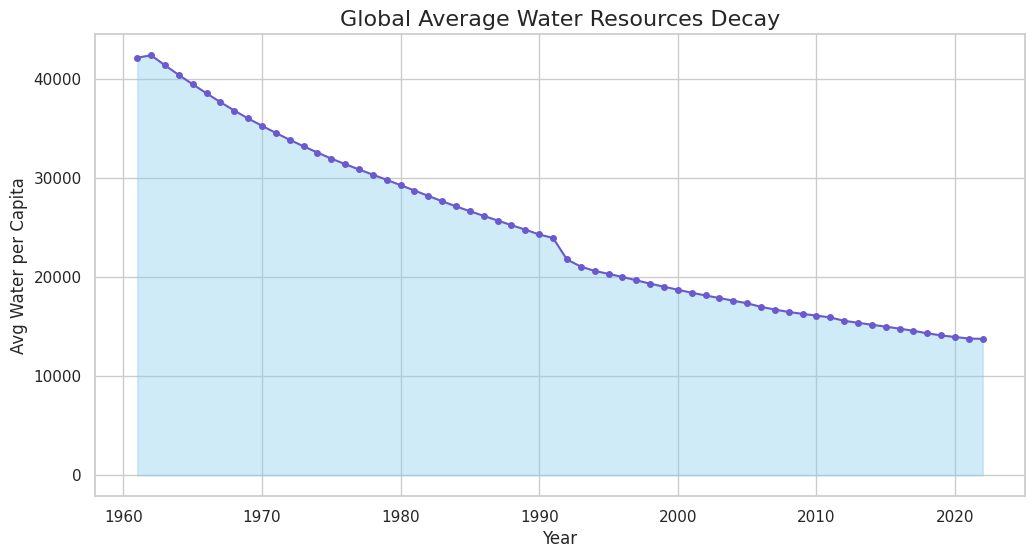

In [ ]:
global_trend = df.groupby('year')['water_value'].mean()
plt.fill_between(global_trend.index, global_trend.values, color="skyblue", alpha=0.4)
plt.plot(global_trend.index, global_trend.values, color="Slateblue", marker='o', markersize=4)
plt.title('Global Average Water Resources Decay')
plt.xlabel('Year')
plt.ylabel('Avg Water per Capita')
plt.show()

# **Comparison of Top vs Bottom Countries**

/tmp/ipykernel_1632/2230904593.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom, x='water_value', y='country', palette='coolwarm')


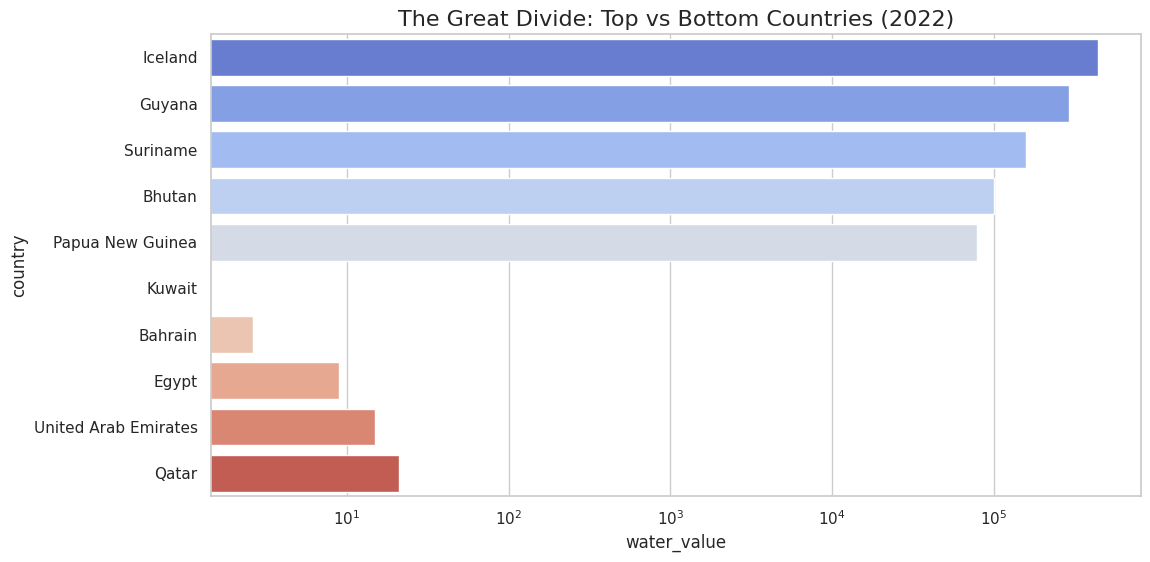

In [ ]:
latest_year = df['year'].max()
top_bottom = pd.concat([df[df['year'] == latest_year].nlargest(5, 'water_value'),
    df[df['year'] == latest_year].nsmallest(5, 'water_value')])

sns.barplot(data=top_bottom, x='water_value', y='country', palette='coolwarm')
plt.title(f'The Great Divide: Top vs Bottom Countries ({latest_year})')
plt.xscale('log')
plt.show()

# **Heatmap of Scarcity Levels**

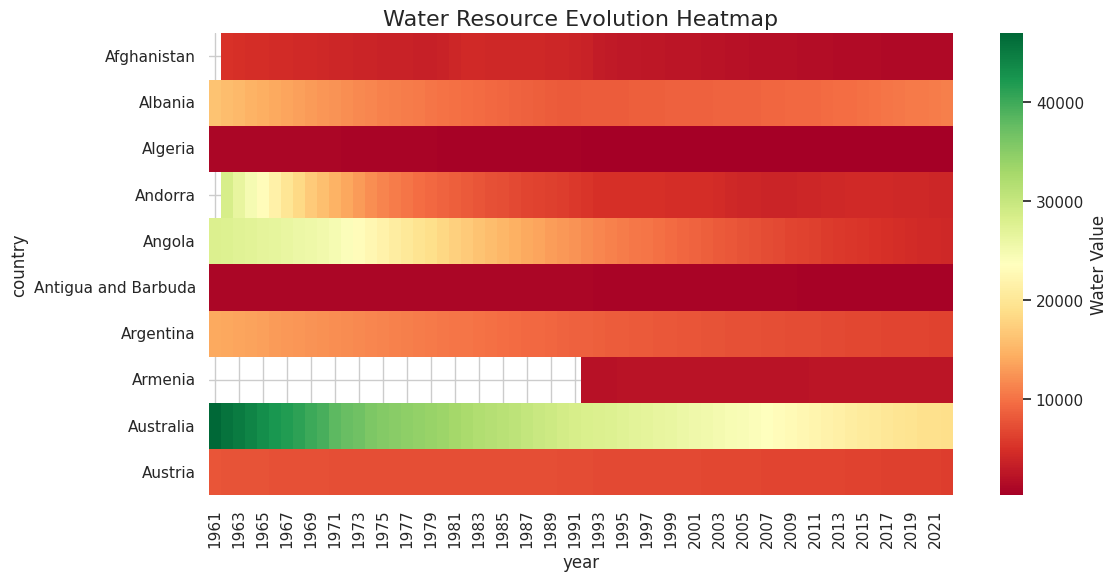

In [ ]:
pivot_status = df[df['country'].isin(df['country'].unique()[:10])].pivot_table(
    index='country', columns='year', values='water_value')
sns.heatmap(pivot_status, cmap='RdYlGn', cbar_kws={'label': 'Water Value'})
plt.title('Water Resource Evolution Heatmap')
plt.show()

# **Correlation Matrix**

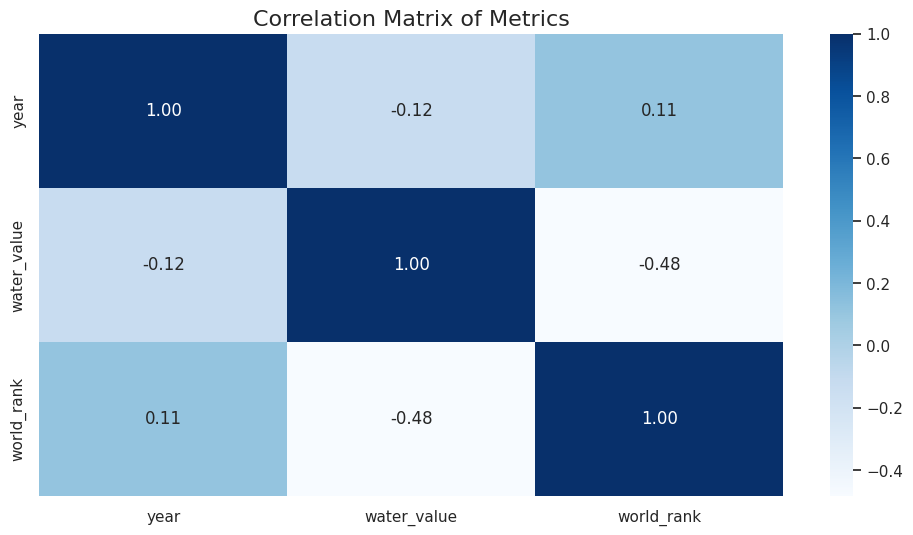

In [ ]:
corr = df[['year', 'water_value', 'world_rank']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Matrix of Metrics')plt.show()

# **Water Scarcity Categories**

In [ ]:
conditions = [(df['water_value'] < 500),
    (df['water_value'] >= 500) & (df['water_value'] < 1000),
    (df['water_value'] >= 1000) & (df['water_value'] < 1700),
    (df['water_value'] >= 1700)]
labels = ['Absolute Scarcity', 'Scarcity', 'Stress', 'Abundant']
df['scarcity_status'] = np.select(conditions, labels, default='Unknown')

# **Century Quarter (Time Segmentation)**

In [ ]:
df['period'] = (df['year'] // 10) * 10

# **Final Save & Export**

In [ ]:
df.to_csv('water_resources_final_analysis.csv', index=False)